In [2]:
# Task 4 – Trend Prediction Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the cleaned Netflix dataset
netflix_dataset = pd.read_csv(
    r"C:\Users\user\Desktop\internship work\TASK 1\netflix_dataset.csv"
)

# Display first 5 rows
netflix_dataset.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_value,duration_unit,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,90,min,2021,9
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1,Season,2021,9
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1,Season,2021,9
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91,min,2021,9
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125,min,2021,9


In [3]:
# Step 1: Prepare release-year data

# Count the number of titles released in each year
yearly_content = (
    netflix_dataset
    .groupby("release_year")
    .size()
    .reset_index(name="content_count")
)

# Sort by release year
yearly_content = yearly_content.sort_values("release_year")

# Display the data
yearly_content.head(10)

,release_year,content_count
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,4
5,1946,2
6,1947,1
7,1954,2
8,1955,3
9,1956,2


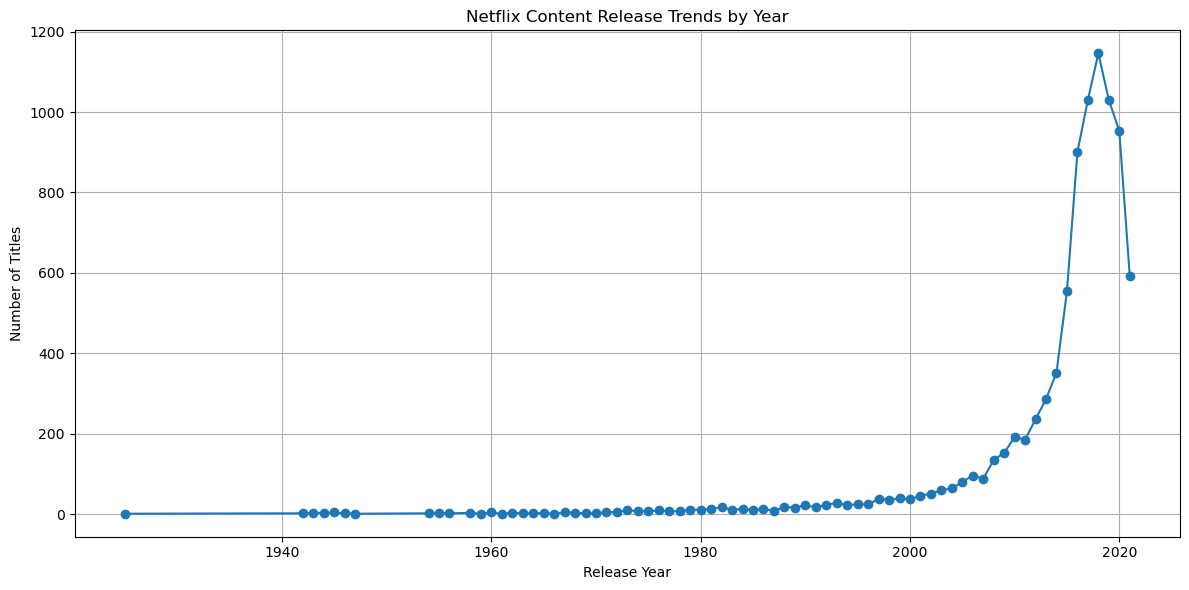

In [4]:
# Step 2: Analyze yearly content trends

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_content["release_year"],
    yearly_content["content_count"],
    marker="o"
)

plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.title("Netflix Content Release Trends by Year")

plt.grid(True)
plt.tight_layout()

plt.show()

In [6]:
# Step 3: Build Forecasting Model

from sklearn.linear_model import LinearRegression

# Prepare the data
X = yearly_content[["release_year"]]
y = yearly_content["content_count"]

# Create and train the model
model = LinearRegression()
model.fit(X, y)

# Display model coefficients
print("Model coefficient:", model.coef_[0])
print("Model intercept:", model.intercept_)



# Create future years for prediction

future_years = np.arange(2022, 2027).reshape(-1, 1)

# Predict future content counts
future_predictions = model.predict(future_years)

# Create prediction table
forecast = pd.DataFrame({
    "year": future_years.flatten(),
    "predicted_content": future_predictions.round(0).astype(int)
})

forecast

Model coefficient: 6.871160836920723
Model intercept: -13510.72085739741


C:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,year,predicted_content
0,2022,383
1,2023,390
2,2024,397
3,2025,403
4,2026,410


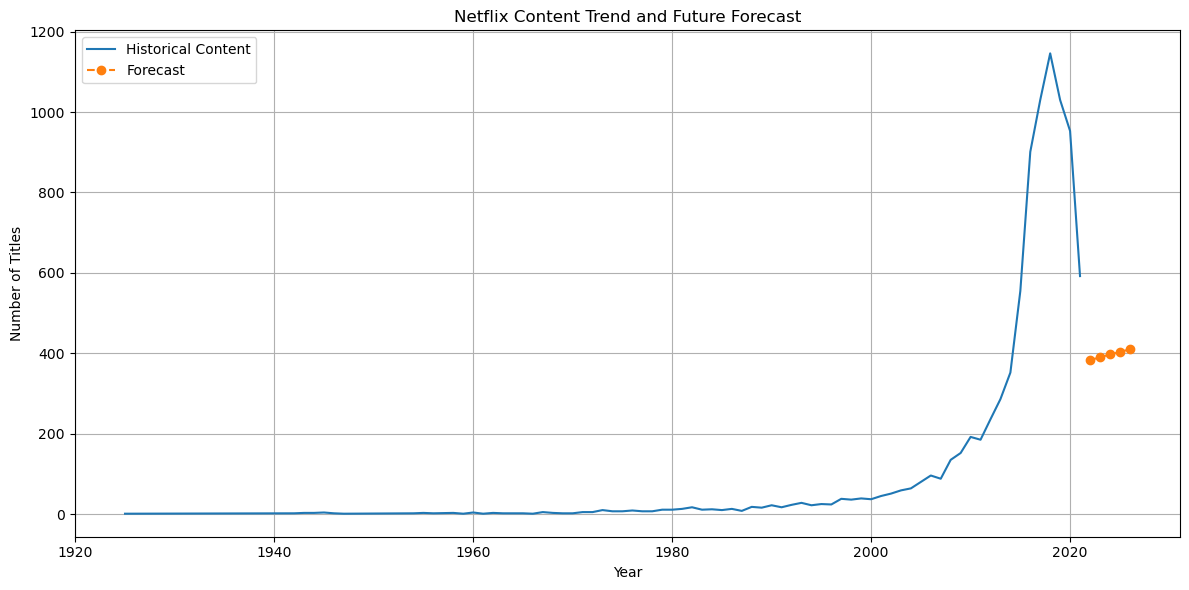

In [7]:
# Step 4: Visualize future predictions

plt.figure(figsize=(12, 6))

# Historical data
plt.plot(
    yearly_content["release_year"],
    yearly_content["content_count"],
    label="Historical Content"
)

# Future predictions
plt.plot(
    forecast["year"],
    forecast["predicted_content"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.title("Netflix Content Trend and Future Forecast")

plt.legend()
plt.grid(True)
plt.tight_layout()

# Save chart as evidence
plt.savefig("task4_future_predictions.png", dpi=300, bbox_inches="tight")

plt.show()

### Step 5: Interpretation of Results

The analysis shows an increasing trend in Netflix content over the years. The linear regression model predicts that the number of titles will continue to increase from approximately 383 titles in 2022 to 410 titles in 2026.

The predicted values increase gradually each year, suggesting continued growth in content based on the historical release-year pattern. However, these predictions are estimates from a simple linear regression model and may not capture other factors that can affect future Netflix content growth.